In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

with open('self_instruct_clean.json') as f:
    data = json.load(f)

df = pd.DataFrame(data)
print(f"Total pairs: {len(df)}")
df.head()


Total pairs: 1247


,generated_id,style,source_answer_id,source_question_id,crop,state,district,season,domain,generated_question,generated_answer,target_state,timestamp
0,si_par_69b4f872_0_1775473081,paraphrase,69b4f872c38a976c56f2388b,69b4f1e2c38a976c56f23805,Pea,Punjab,General,Rabi,Disease,What are the typical root diseases affecting p...,Root diseases in peas represent a major challe...,,2026-04-06T10:58:01.989026
1,si_par_69ab9f3b_0_1775473087,paraphrase,69ab9f3bc2b602929b3707e3,69ab9d5ec2b602929b3706d0,Maize Makka,Punjab,PATIALA,Kharif,Fertilizer and Nutrient,What is the recommended foliar spray compositi...,There is no fertilizer named 20:20:13. However...,,2026-04-06T10:58:07.073432
2,si_par_69b3b36c_0_1775473092,paraphrase,69b3b36ce42ed6415b95d421,69b3b13ee42ed6415b95d34b,Berseem,Punjab,General,Rabi,Pest,What are the control measures for Bihar hairy ...,Bihar hairy caterpillar and gram caterpillar a...,,2026-04-06T10:58:12.267297
3,si_par_698c01cf_0_1775473097,paraphrase,698c01cf6bca0c342047d01b,698bff986bca0c342047cf71,Cotton,Punjab,BHATINDA,Kharif,Cultural Practices,What is the proper method for boll opening (gl...,Blooming and boll opening are both different s...,,2026-04-06T10:58:17.534268
4,si_par_698c030f_0_1775473101,paraphrase,698c030f6bca0c342047d07c,698bff986bca0c342047cf40,Cotton,Punjab,MANSA,Kharif,Fertilizer and Nutrient,What is the suggested fertilizer application s...,To ensure effective cotton (Kapas/Narma) farmi...,,2026-04-06T10:58:21.829597


In [2]:
print("=== DATASET SUMMARY ===")
print(f"Total clean pairs : {len(df)}")
print(f"Unique crops      : {df['crop'].nunique()}")
print(f"Unique states     : {df['state'].nunique()}")
print(f"Unique domains    : {df['domain'].nunique()}")
print()
print("Style breakdown:")
print(df['style'].value_counts())

=== DATASET SUMMARY ===
Total clean pairs : 1247
Unique crops      : 20
Unique states     : 7
Unique domains    : 25

Style breakdown:
style
harder        374
related       360
paraphrase    302
localize      211
Name: count, dtype: int64


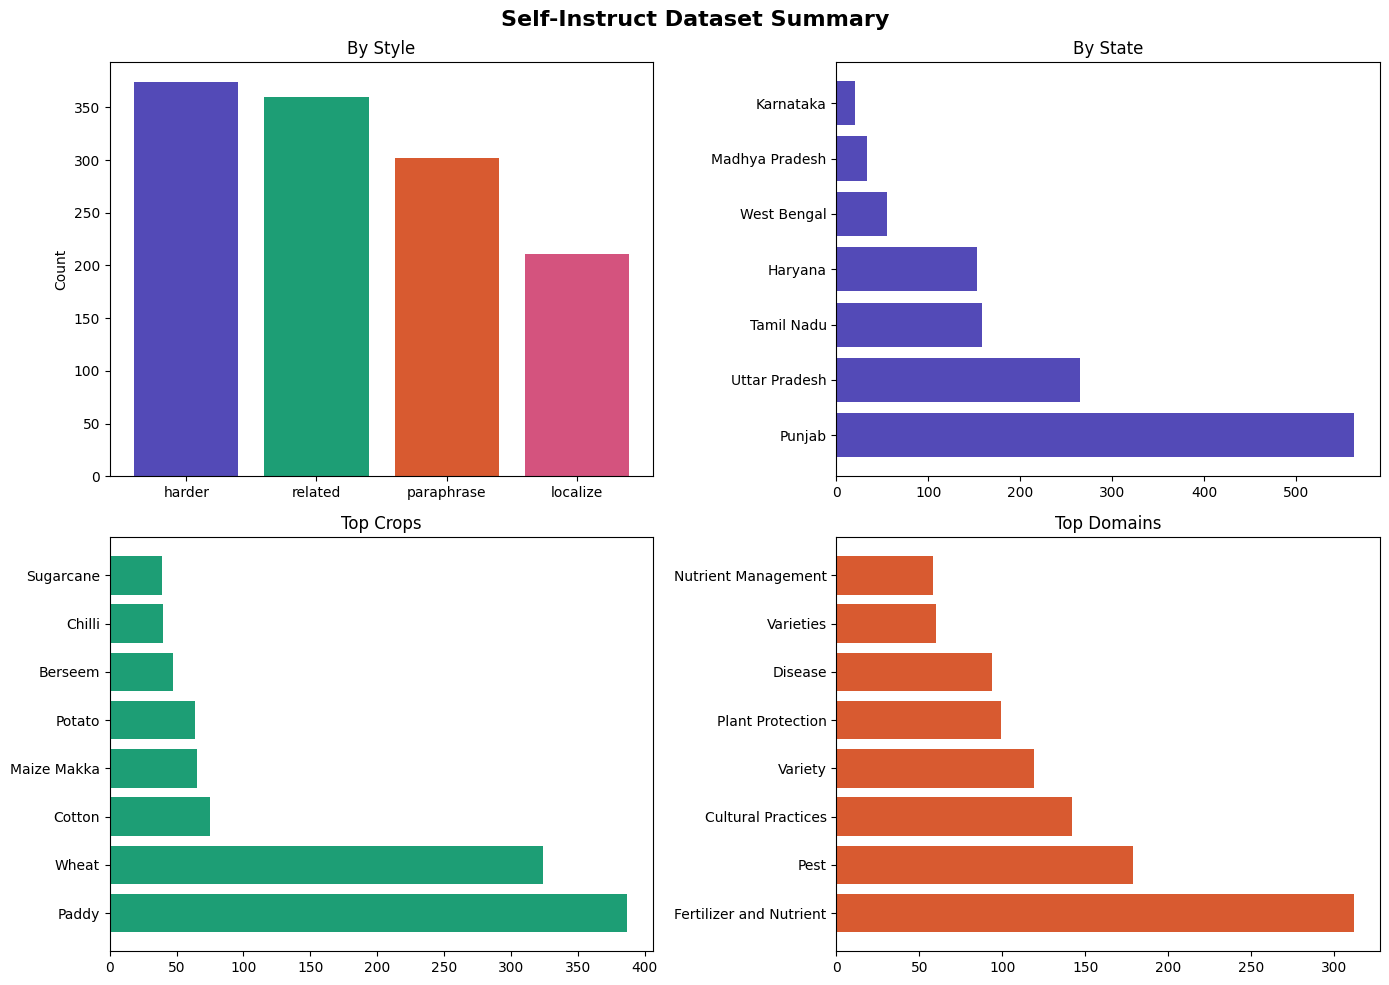

Saved: summary_plot.png


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Self-Instruct Dataset Summary', fontsize=16, fontweight='bold')

# Style
style_counts = df['style'].value_counts()
axes[0,0].bar(style_counts.index, style_counts.values, color=['#534AB7','#1D9E75','#D85A30','#D4537E'])
axes[0,0].set_title('By Style')
axes[0,0].set_ylabel('Count')

# State
state_counts = df['state'].value_counts()
axes[0,1].barh(state_counts.index, state_counts.values, color='#534AB7')
axes[0,1].set_title('By State')

# Top crops
crop_counts = df['crop'].value_counts().head(8)
axes[1,0].barh(crop_counts.index, crop_counts.values, color='#1D9E75')
axes[1,0].set_title('Top Crops')

# Top domains
domain_counts = df['domain'].value_counts().head(8)
axes[1,1].barh(domain_counts.index, domain_counts.values, color='#D85A30')
axes[1,1].set_title('Top Domains')

plt.tight_layout()
plt.savefig('summary_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: summary_plot.png")

In [4]:
# Filter karo crop aur style se
crop_filter = 'Wheat'      # change karo
style_filter = 'paraphrase' # change karo

filtered = df[(df['crop']==crop_filter) & (df['style']==style_filter)]
print(f"Found: {len(filtered)} pairs\n")

for _, row in filtered.head(5).iterrows():
    print(f"State  : {row['state']}")
    print(f"Domain : {row['domain']}")
    print(f"Q: {row['generated_question']}")
    print(f"A: {row['generated_answer'][:300]}...")
    print("-"*60)
    

Found: 81 pairs

State  : Karnataka
Domain : Seeds
Q: What is the recommended seed rate for wheat in Karnataka?
A: For optimal wheat production in Karnataka, the seed rate must be determined based on irrigation status and sowing time. In irrigated and timely sown conditions, apply 40 kg of seed per acre with a row spacing of 20–23 cm. For irrigated late-sown wheat, apply 50 kg per acre while maintaining a row sp...
------------------------------------------------------------
State  : Uttar Pradesh
Domain : Variety
Q: What are the traits and cultivation information of Sultan and Rudraksh wheat varieties?
A: I appreciate your interest in wheat varieties for Uttar Pradesh. However, I must inform you that Sultan and Rudraksh are NOT recognized wheat varieties approved by the Indian Council of Agricultural Research (ICAR) or recommended by any state agricultural universities for cultivation in Uttar Prades...
------------------------------------------------------------
State  : Uttar Prades